In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
import numpy as np

def average_shifted_histogram(data, h, m, x0=None):
 
    data = np.asarray(data)
    n = len(data)

    if x0 is None:
        x0 = data.min()

    xmin = data.min()
    xmax = data.max()
    bins = np.arange(xmin, xmax + h, h)
    ash_density = np.zeros(len(bins) - 1)

    for j in range(m):
        shift = x0 + j * h / m
        shifted_bins = bins + shift

        counts, _ = np.histogram(data, bins=shifted_bins)
        density = counts / (n * h)

        ash_density += density

    ash_density /= m
    bin_centers = bins[:-1] + h / 2

    return bin_centers, ash_density


In [17]:
import matplotlib.pyplot as plt


np.random.seed(42)

data = np.concatenate([
    np.random.normal(1.5, 0.25, 400),
    np.random.normal(2.3, 0.15, 100)
])
data 

array([1.62417854, 1.46543392, 1.66192213, 1.88075746, 1.44146166,
       1.44146576, 1.8948032 , 1.69185868, 1.3826314 , 1.63564001,
       1.38414558, 1.38356756, 1.56049057, 1.02167994, 1.06877054,
       1.35942812, 1.24679222, 1.57856183, 1.27299398, 1.14692407,
       1.86641219, 1.44355592, 1.51688205, 1.14381295, 1.36390432,
       1.52773065, 1.21225161, 1.5939245 , 1.34984033, 1.42707656,
       1.34957335, 1.96306955, 1.49662569, 1.23557227, 1.70563623,
       1.19478909, 1.5522159 , 1.01008247, 1.16795349, 1.54921531,
       1.68461664, 1.54284207, 1.47108793, 1.42472408, 1.1303695 ,
       1.32003895, 1.38484031, 1.76428056, 1.58590457, 1.05923996,
       1.58102099, 1.40372943, 1.3307695 , 1.65291907, 1.75774988,
       1.73282003, 1.29019562, 1.42269691, 1.58281586, 1.74388628,
       1.38020644, 1.45358526, 1.22341626, 1.20094834, 1.70313146,
       1.83906001, 1.48199747, 1.75088322, 1.59040901, 1.33872006,
       1.5903489 , 1.88450914, 1.49104349, 1.89116091, 0.84506

In [19]:
q75, q25 = np.percentile(data, [75, 25])
iqr = q75 - q25
n = len(data)

h = 2 * iqr / n**(1/3)
h
m = 8


In [20]:
x, ash = average_shifted_histogram(data, h=h, m=m)


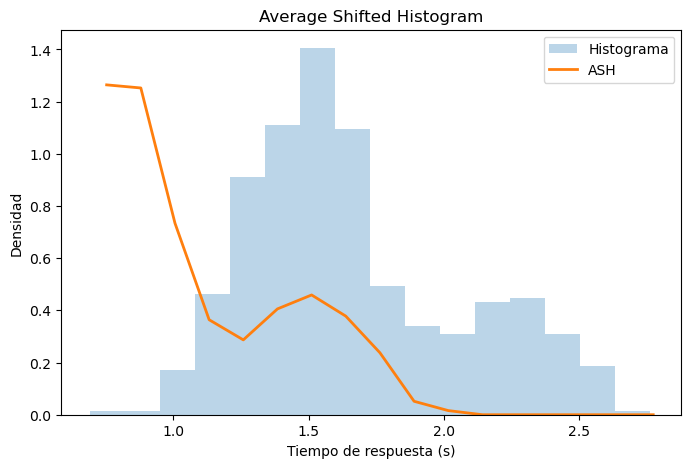

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(data, bins=int((data.max()-data.min())/h),
         density=True, alpha=0.3, label="Histograma")

plt.plot(x, ash, lw=2, label="ASH")
plt.xlabel("Tiempo de respuesta (s)")
plt.ylabel("Densidad")
plt.title("Average Shifted Histogram")
plt.legend()
plt.show()
